In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


Load dataset

In [72]:
df = pd.read_csv('diabetes.csv')

Explore Data

In [73]:
df.shape

(768, 9)

In [74]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [76]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Fix the zeros

In [77]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [78]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())
print("Zeros remaining:")
print((df[zero_cols] == 0).sum())
print("\nNull values remaining:")
print(df[zero_cols].isnull().sum())

Zeros remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Null values remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


EDA & Visualization

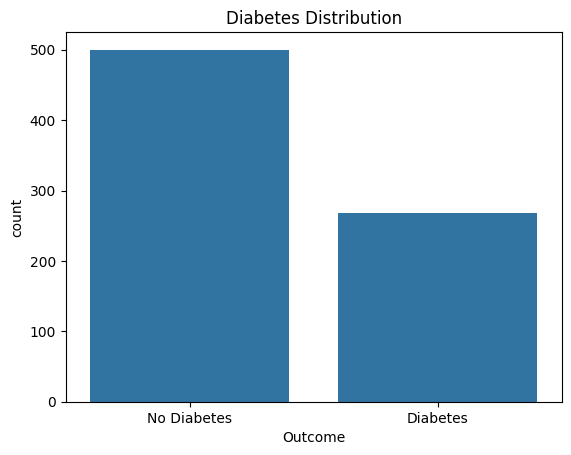

In [79]:
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Distribution')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

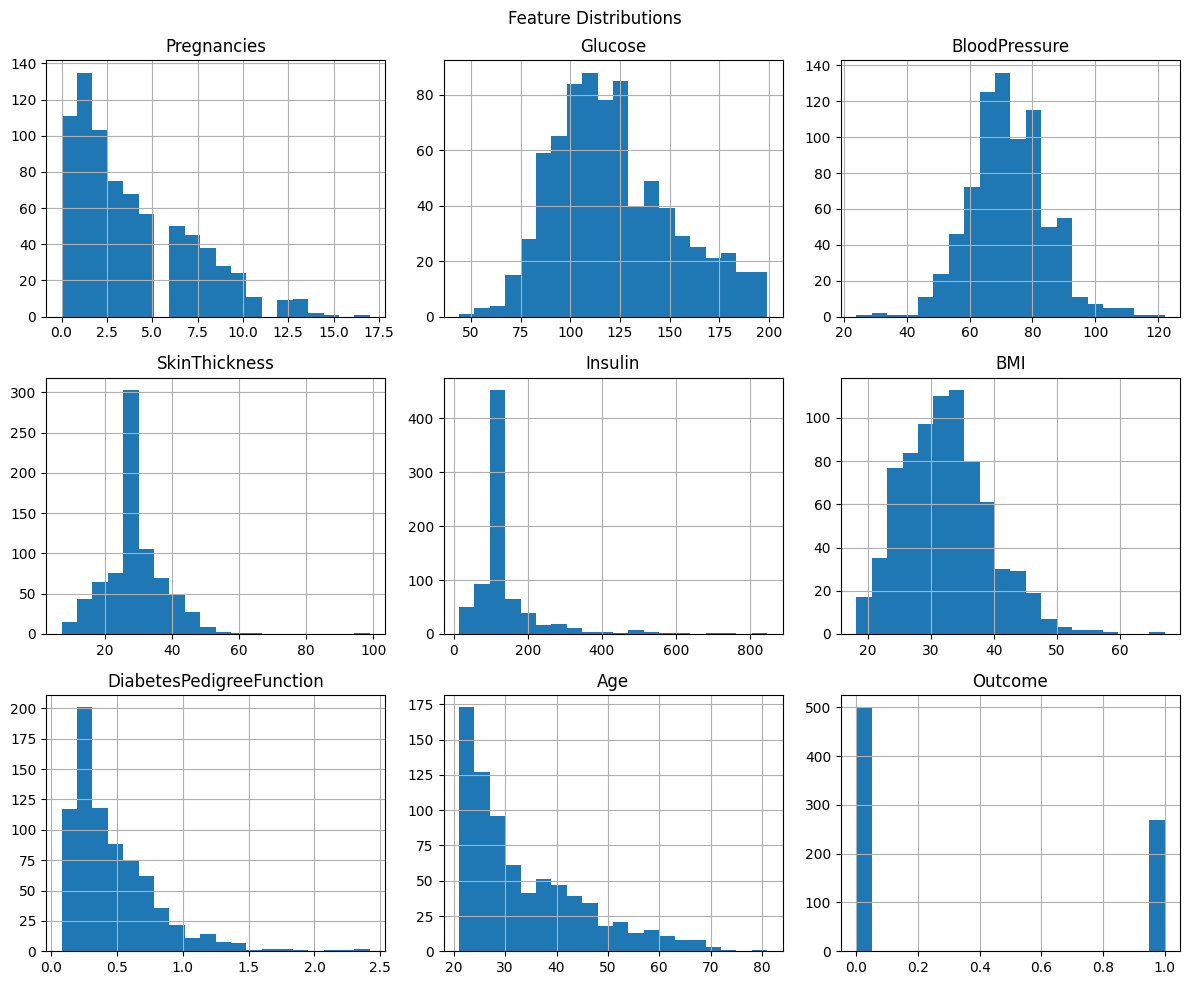

In [80]:
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

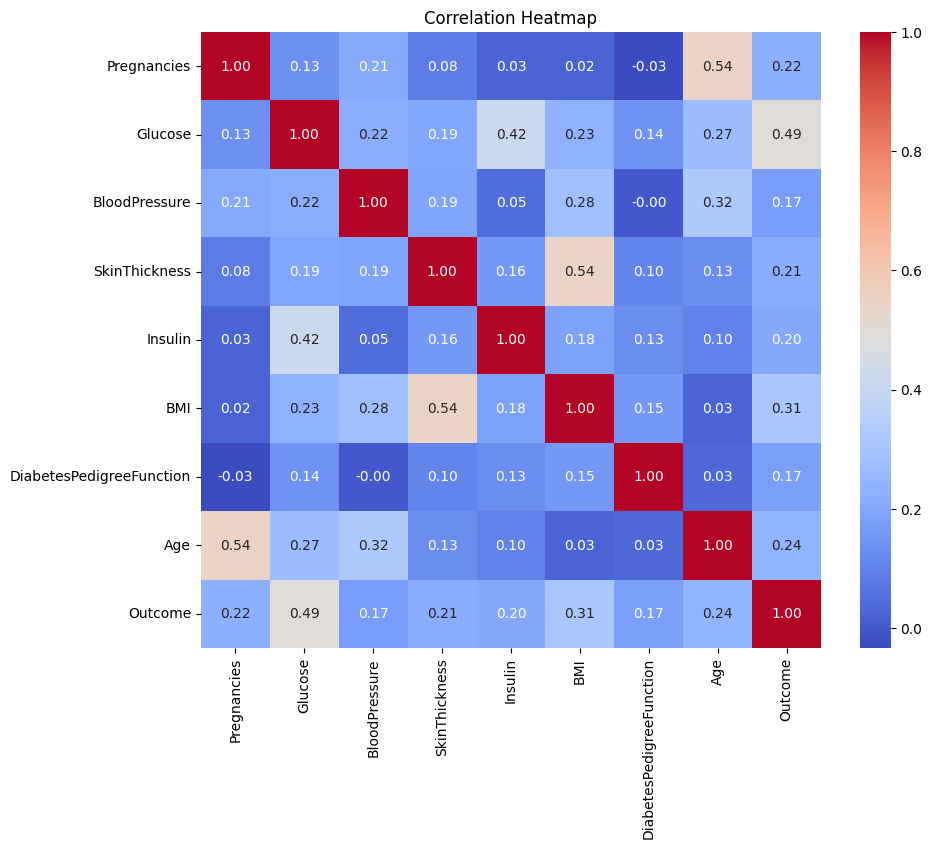

In [81]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

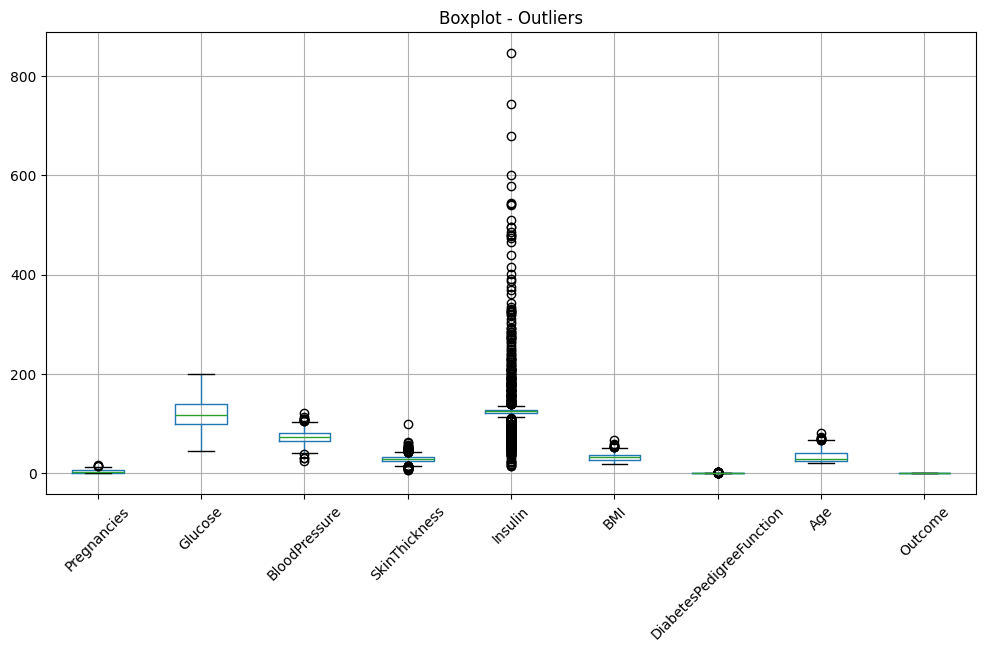

In [82]:
plt.figure(figsize=(12, 6))
df.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot - Outliers')
plt.show()

handle outliers

In [83]:
cols = ['Glucose', 'BloodPressure', 'BMI', 'Age']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[~((df[col] < (Q1 - 1.5 * IQR)) |
              (df[col] > (Q3 + 1.5 * IQR)))]

print("After outliers:", df.shape)

After outliers: (738, 9)


Feature Scaling & Split

In [84]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train: (590, 8)
X_test: (148, 8)


Compare All Models

In [85]:
models = {
    'Logistic Regression' : LogisticRegression(random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'SVM'                 : SVC(random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'XGBoost'             : XGBClassifier(random_state=42)
}

# Compare
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'Std':>10}")
print("=" * 50)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, 
                             cv=5, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")

print("=" * 50)
best = max(results, key=results.get)
print(f"\n🏆 Best Model: {best} ({results[best]:.4f})")

Model                       Accuracy        Std
Logistic Regression           0.7610     0.0248
KNN                           0.7220     0.0189
SVM                           0.7475     0.0230
Decision Tree                 0.7136     0.0440
Random Forest                 0.7576     0.0366
Gradient Boosting             0.7746     0.0301
Naive Bayes                   0.7373     0.0257
XGBoost                       0.7559     0.0189

🏆 Best Model: Gradient Boosting (0.7746)



=== Logistic Regression ===
Accuracy: 0.7838

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.83      0.87      0.85       104
    Diabetes       0.65      0.59      0.62        44

    accuracy                           0.78       148
   macro avg       0.74      0.73      0.73       148
weighted avg       0.78      0.78      0.78       148



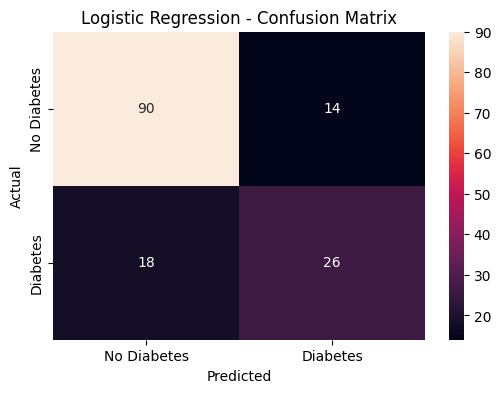


=== Gradient Boosting ===
Accuracy: 0.7365

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.77      0.80       104
    Diabetes       0.55      0.66      0.60        44

    accuracy                           0.74       148
   macro avg       0.69      0.71      0.70       148
weighted avg       0.75      0.74      0.74       148



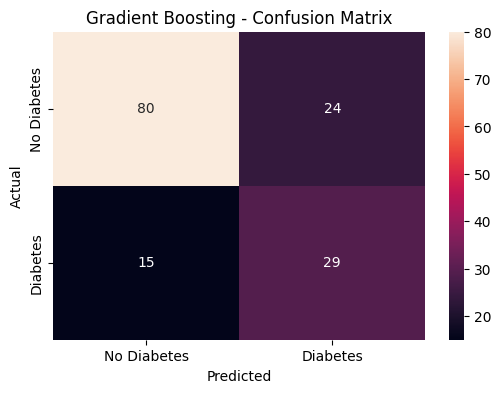

In [88]:
# Define both models
models = {
    'Logistic Regression' : LogisticRegression(random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42)
}

# Train, Predict, Evaluate both
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    print(f"\n{'='*45}")
    print(f"=== {name} ===")
    print(f"{'='*45}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Diabetes']))
    
    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Hyperparameter Tuning

In [89]:
from sklearn.model_selection import GridSearchCV

# ================================
# 1. Tune Logistic Regression
# ================================
lr_params = {
    'C'          : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'    : ['l1', 'l2'],
    'solver'     : ['liblinear', 'saga'],
    'max_iter'   : [100, 200, 500]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='recall',   # recall most important for medical!
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print("=== Logistic Regression ===")
print(f"Best Params : {lr_grid.best_params_}")
print(f"Best Recall : {lr_grid.best_score_:.4f}")

# ================================
# 2. Tune Gradient Boosting
# ================================
gb_params = {
    'n_estimators'  : [50, 100, 200],
    'learning_rate' : [0.01, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='recall',   # recall most important!
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train, y_train)

print("\n=== Gradient Boosting ===")
print(f"Best Params : {gb_grid.best_params_}")
print(f"Best Recall : {gb_grid.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
=== Logistic Regression ===
Best Params : {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall : 0.7016
Fitting 5 folds for each of 54 candidates, totalling 270 fits

=== Gradient Boosting ===
Best Params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Recall : 0.6774



=== Tuned Logistic Regression ===
Accuracy : 0.7162
              precision    recall  f1-score   support

 No Diabetes       0.88      0.69      0.77       104
    Diabetes       0.52      0.77      0.62        44

    accuracy                           0.72       148
   macro avg       0.70      0.73      0.70       148
weighted avg       0.77      0.72      0.73       148



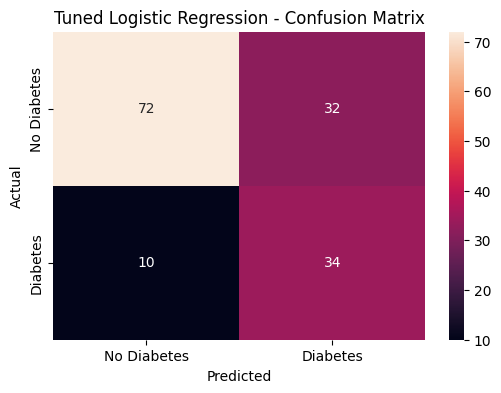


=== Tuned Gradient Boosting ===
Accuracy : 0.7365
              precision    recall  f1-score   support

 No Diabetes       0.84      0.77      0.80       104
    Diabetes       0.55      0.66      0.60        44

    accuracy                           0.74       148
   macro avg       0.69      0.71      0.70       148
weighted avg       0.75      0.74      0.74       148



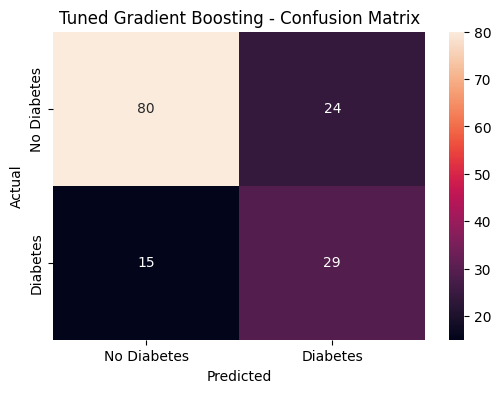

In [90]:
# Compare before and after tuning
for name, grid in [('Logistic Regression', lr_grid),
                   ('Gradient Boosting', gb_grid)]:
    y_pred = grid.predict(X_test)
    
    print(f"\n{'='*45}")
    print(f"=== Tuned {name} ===")
    print(f"{'='*45}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Diabetes']))
    
    # Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'Tuned {name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [94]:
# Save the tuned logistic regression model
joblib.dump(lr_grid.best_estimator_, 'diabetes_model.pkl')

# Save the scaler too! Very important!
joblib.dump(scaler, 'diabetes_scaler.pkl')

print("Model saved → diabetes_model.pkl")
print("Scaler saved → diabetes_scaler.pkl")

Model saved → diabetes_model.pkl
Scaler saved → diabetes_scaler.pkl
